# 09 - Sentetik Telemetri: Ham Üretim, Segmentasyon ve Özellik Çıkarımı
## Uydu Telemetri Anomali Tespiti

ESA OPS-SAT telemetrisini gerçek yaşam döngüsüne sadık şekilde sentetik üretmek. 
Tek adımda hazır segmentler üretmek yerine, gerçek veride olduğu gibi üç ayrı aşama izlenir:

```
Aşama 1              Aşama 2                 Aşama 3
Ham sürekli akış --> Hibrit segmentasyon --> ESA feature extraction
                     segments.csv            dataset.csv
```

OPS-SAT verisinde segmentler doğal değildir, sürekli bir downlink akışı, sonradan pencereler hâlinde bölünmüş ve insan eliyle seçilmiştir. 

- Aşama 1 sürekli ham akış üretir, segment sınırı veya etiket yok. Anomaliler akışa enjekte edilir, örnek-bazlı bir ground-truth maskesi tutulur.
- Aşama 2 akışı hibrit bir algoritmayla segmentlere böler. Anomali etiketi atanmaz, türetilir: segment anomaliyi anlamlı oranda içeriyorsa anomalidir.
- Aşama 3 her segmentten ESA'nın 18 handcrafted özelliğini çıkarır (Notebook 10 ile aynı pipeline).

Her aşama orijinal veriyi baz alır: sinyal istatistikleri, segment uzunluk dağılımı, örnekleme ve boşluk yapısı `data/channel_profiles.json`'dan türetilmiştir.

`src/synthetic_generator.py` (Aşama 1) · `src/feature_engineer.py` (Aşama 2-3)

### İçindekiler
1. Hazırlık ve Kanal Profilleri
2. Sürekli Sinyal Modelleri
3. Anomali Enjeksiyonu (6 Tür)
4. Onboard Operasyonel Artefaktlar (5 Tür)
5. Aşama 1, Sürekli Ham Akış Üretimi
6. Aşama 2, Hibrit Segmentasyon
7. Aşama 3, ESA Feature Extraction
8. Doğrulama
9. Kaydetme ve Pipeline Özeti


---
## Bölüm 1: Hazırlık ve Kanal Profilleri
Üretici modülleri ve gerçek veriden çıkarılmış kanal istatistiklerini yüklüyoruz. Bu profiller (`channel_profiles.json`) hem sinyal üretiminin hem de segmentasyonun referans gerçekliğidir.


In [2]:
import sys, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 110

sys.path.insert(0, '..')
from src.synthetic_generator import SyntheticTelemetryGenerator, CHANNEL_PROFILES, ANOMALY_TYPES
from src.feature_engineer import segment_raw_telemetry, extract_esa_features

print('Aşama 1 (üretici), Aşama 2 (segmentleyici), Aşama 3 (feature) yüklendi.')
print(f'Kanal profili: {len(CHANNEL_PROFILES)} | Anomali türü: {len(ANOMALY_TYPES)} -> {ANOMALY_TYPES}')


Aşama 1 (üretici), Aşama 2 (segmentleyici), Aşama 3 (feature) yüklendi.
Kanal profili: 7 | Anomali türü: 6 -> ['spike', 'shift', 'noise', 'gap', 'flat', 'deformation']


In [3]:
prof_rows = []
for ch, p in CHANNEL_PROFILES.items():
    prof_rows.append({
        'Kanal': ch, 'Tip': p['type'],
        'Sinyal Ort.': p['signal_mean'], 'Sinyal Std': p['signal_std'],
        'Maks': p['signal_max'], 'Örnekleme': p['sampling_options'],
        'Uzunluk Ort.': p['len_mean'], 'Uzunluk Std': p['len_std'],
        'Veri Oranı (w)': p['weight'],
    })
pd.DataFrame(prof_rows)


,Kanal,Tip,Sinyal Ort.,Sinyal Std,Maks,Örnekleme,Uzunluk Ort.,Uzunluk Std,Veri Oranı (w)
0,CADC0872,magnetometer,9.840000e-07,0.000022,0.000065,"[1, 5]",122,115,0.26
1,CADC0873,magnetometer,-1.130000e-06,0.000021,0.000060,"[1, 5]",115,111,0.28
2,CADC0874,magnetometer,3.230000e-06,0.000020,0.000101,"[1, 5]",303,256,0.09
3,CADC0884,photodiode,4.710000e-01,0.391000,1.570800,[5],75,39,0.07
4,CADC0888,photodiode,2.650000e-01,0.338000,1.301900,[5],46,22,0.12
5,CADC0892,photodiode,2.550000e-01,0.331000,1.570800,"[1, 5]",236,93,0.10
6,CADC0894,photodiode,1.140000e-01,0.209000,1.400300,"[1, 5]",247,230,0.07


---
## Bölüm 2: Sürekli Sinyal Modelleri
Bu mimaride sinyaller sürekli akış olarak üretilir. İki kanal ailesi için fiziksel olarak gerekçeli ayrı modeller vardır:

- Manyetometre, Ornstein-Uhlenbeck süreci: Ortalamaya geri dönen bir rastgele yürüyüş. Durağan standart sapması profilin `signal_std`'sine eşittir. Herhangi bir pencereye bakıldığında yerel olarak düzgün bir trend görülür, gerçek manyetometre davranışı.
- Fotodiyot, yörünge-periyodik döngü: Güneş açısının yörünge boyunca değişimini taklit eden, düşük-değer eğilimli sinüzoidal döngü.

Aşağıda iç metotları (`_gen_*_continuous`) doğrudan çağırarak uzun sürekli akışları görselleştiriyoruz.


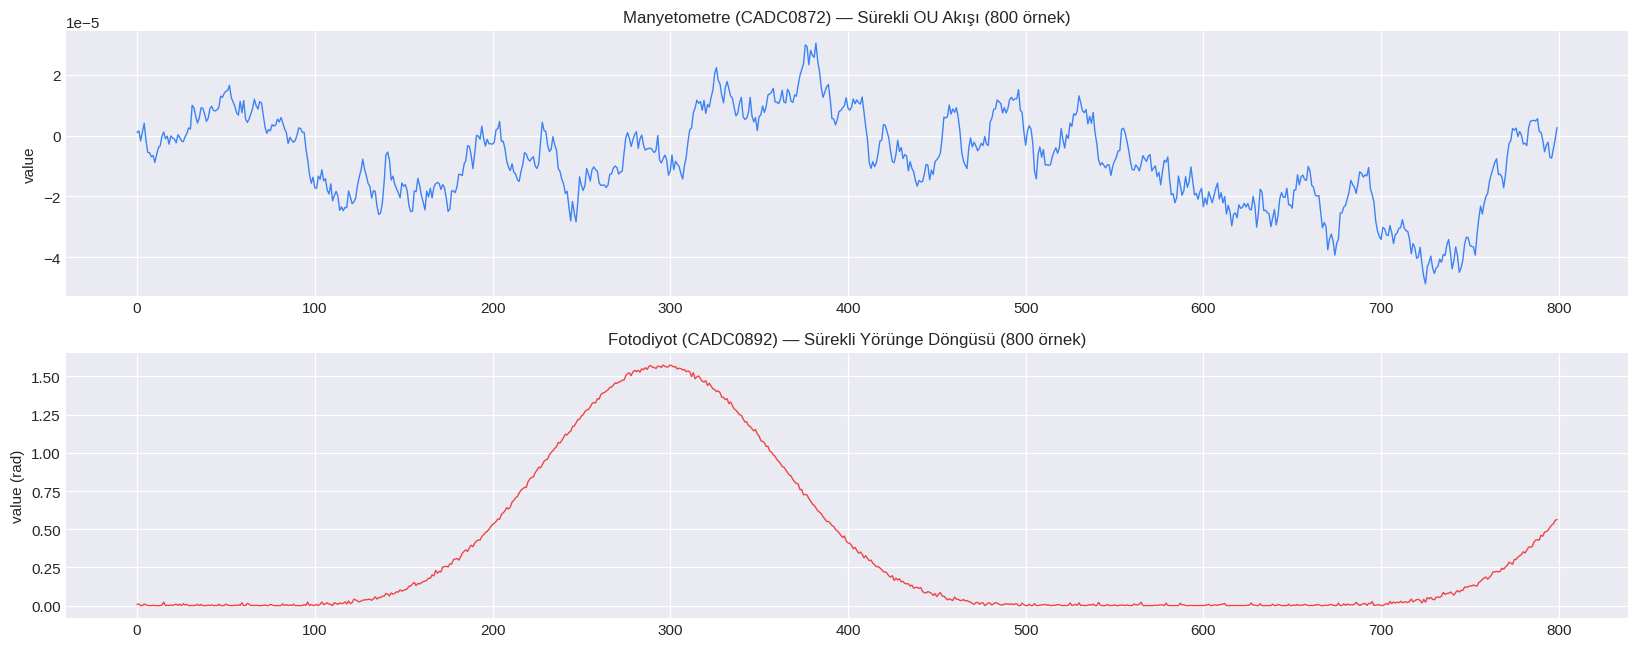

Manyetometre std: üretilen=1.46e-05  hedef=2.15e-05
Fotodiyot ort/max: üretilen=0.22  gerçek ~0.27


In [4]:
gen = SyntheticTelemetryGenerator(seed=42)

fig, axes = plt.subplots(2, 1, figsize=(15, 6))

mag = gen._gen_magnetometer_continuous(800, CHANNEL_PROFILES['CADC0872'])
axes[0].plot(mag, color='#3B82F6', linewidth=0.9)
axes[0].set_title('Manyetometre (CADC0872) — Sürekli OU Akışı (800 örnek)', fontsize=11)
axes[0].set_ylabel('value')

pdc = gen._gen_photodiode_continuous(800, CHANNEL_PROFILES['CADC0892'])
axes[1].plot(pdc, color='#EF4444', linewidth=0.9)
axes[1].set_title('Fotodiyot (CADC0892) — Sürekli Yörünge Döngüsü (800 örnek)', fontsize=11)
axes[1].set_ylabel('value (rad)')

plt.tight_layout()
plt.show()

print(f'Manyetometre std: üretilen={mag.std():.2e}  hedef={CHANNEL_PROFILES["CADC0872"]["signal_std"]:.2e}')
print(f'Fotodiyot ort/max: üretilen={pdc.mean()/CHANNEL_PROFILES["CADC0892"]["signal_max"]:.2f}  gerçek ~0.27')


---
## Bölüm 3: Anomali Enjeksiyonu
Anomaliler sürekli akışa enjekte edilir. 6 tür, gerçek uydu arızalarının sınıflarını temsil eder:

| Tür | Fiziksel Karşılığı |
|-----|--------------------|
| spike | Ani parazit veya kozmik ışın |
| shift | Kalıcı kalibrasyon kayması |
| noise | Sensör bozulması |
| gap | İletişim kesintisi |
| flat | Sensör donması |
| deformation | Mekanik titreşim |


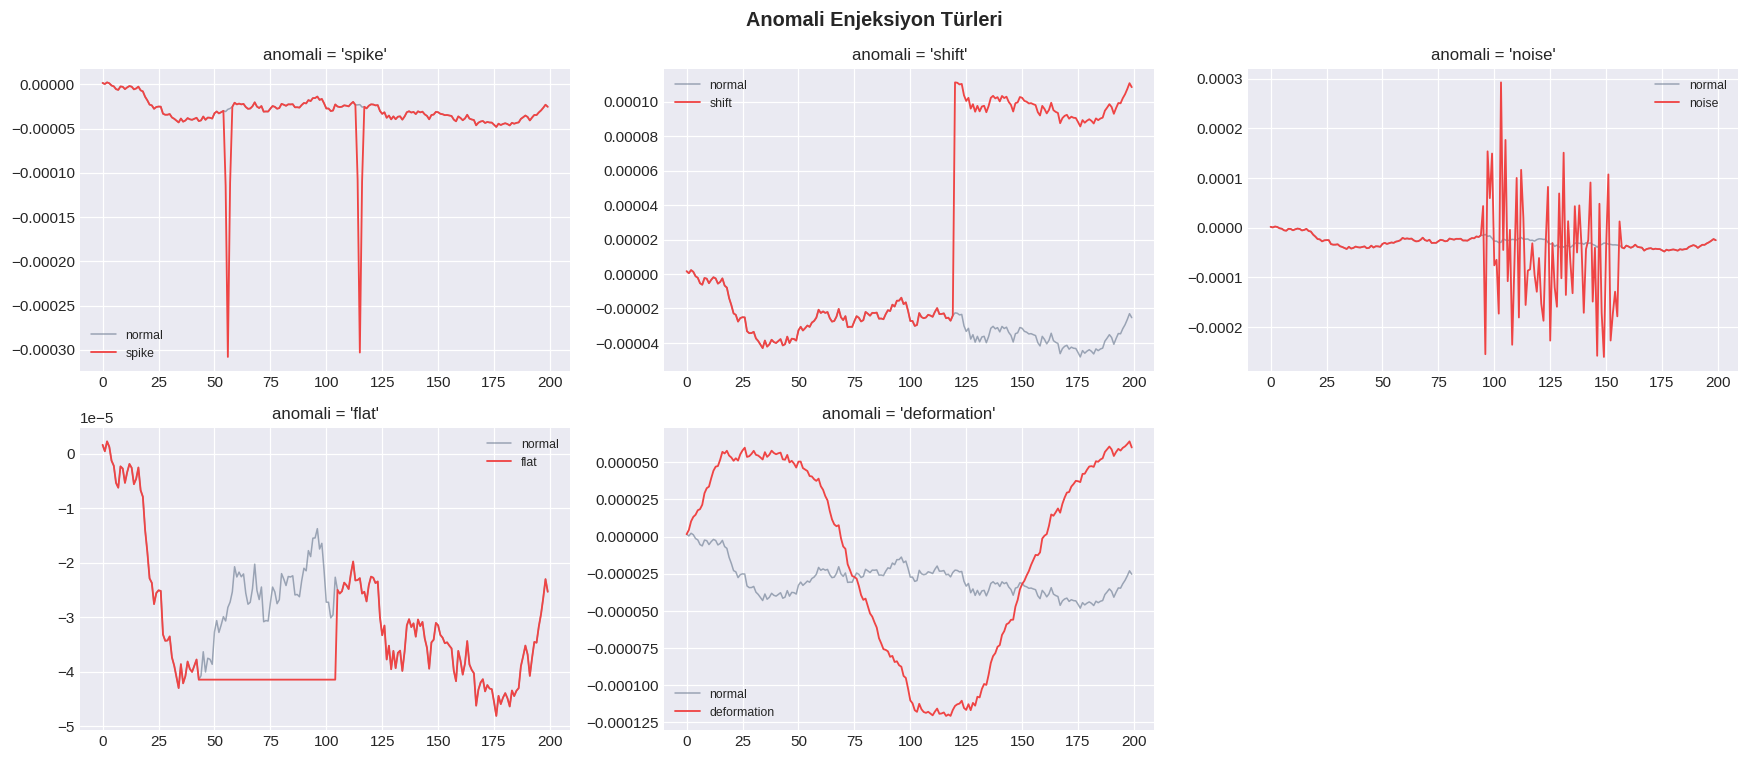

In [6]:
gen = SyntheticTelemetryGenerator(seed=7)
mag_prof = CHANNEL_PROFILES['CADC0872']
base = gen._gen_magnetometer_continuous(200, mag_prof)
injectors = {'spike': gen._inject_spike, 'shift': gen._inject_shift,
             'noise': gen._inject_noise, 'flat': gen._inject_flat,
             'deformation': gen._inject_deformation}

fig, axes = plt.subplots(2, 3, figsize=(16, 7)); axes = axes.flatten()
for ax, (name, fn) in zip(axes, injectors.items()):
    inj = fn(base.copy(), mag_prof)
    ax.plot(base, color='#64748B', alpha=0.6, linewidth=1.0, label='normal')
    ax.plot(inj, color='#EF4444', linewidth=1.2, label=name)
    ax.set_title(f"anomali = '{name}'", fontsize=11); ax.legend(fontsize=8)
axes[5].axis('off')
plt.suptitle('Anomali Enjeksiyon Türleri', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


---
## Bölüm 4: Onboard Operasyonel Artefaktlar
Anomali olmayan ama sinyali bozan operasyonel olaylar. Gerçek OPS-SAT oranlarıyla enjekte edilir ve segment içinde kalmalıdır (segmentasyon bunları bölmemelidir, `gaps_squared` özelliğine katkı verirler).

| Artefakt | Normal | Anomali |
|----------|--------|---------|
| Mikro-boşluk (Δt iki katı) | %22 | %51 |
| Sıfır-zaman farkı (Δt=0) | %21 | %42 |
| Sıfır-değer | %15 | %22 |
| Sabit-değer | %10 | %18 |
| Büyük boşluk (10-130s) |, | %6 |


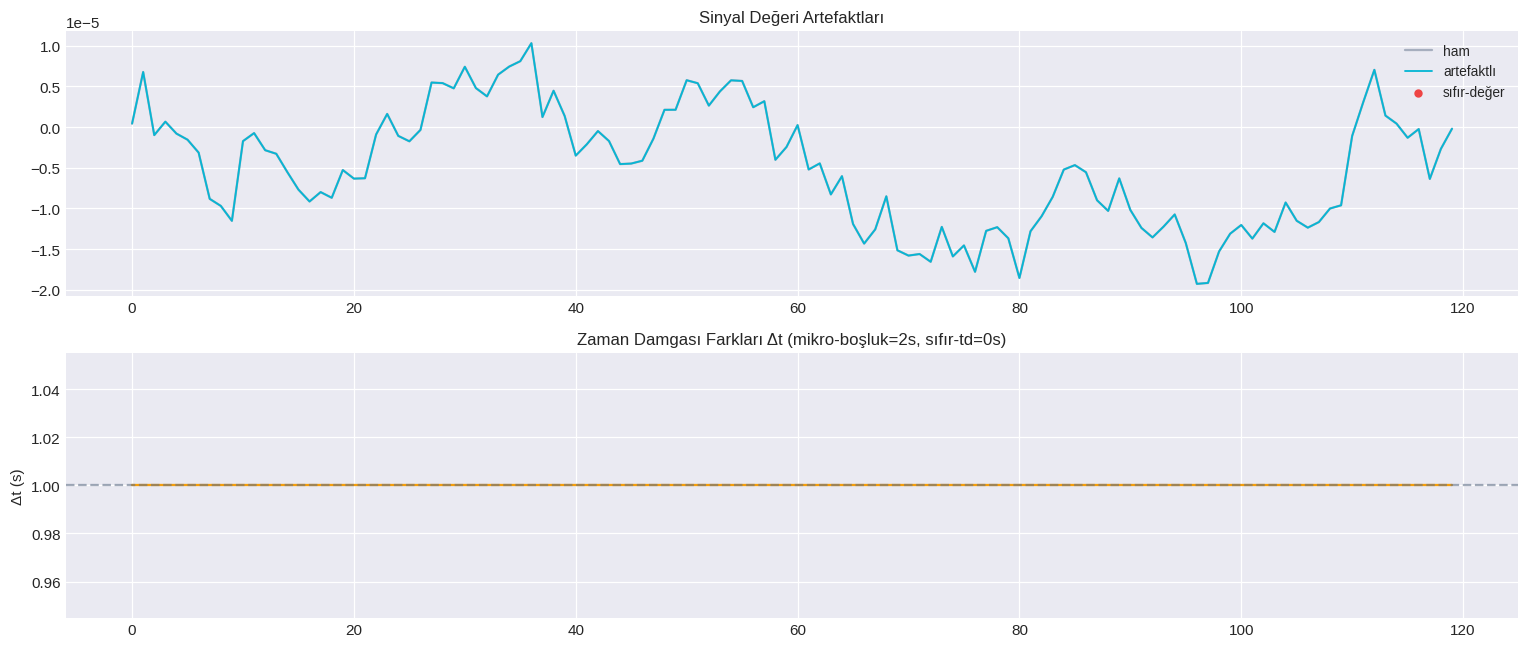

Sıfır-değer: 0 | sıfır-td: 0 | mikro-boşluk: 0


In [7]:
gen = SyntheticTelemetryGenerator(seed=3)
prof = CHANNEL_PROFILES['CADC0872']
sig = gen._gen_magnetometer_continuous(120, prof)
ts = gen._generate_timestamps(120, sampling=1)
sig_art, ts_art = gen._apply_onboard_artifacts(sig.copy(), ts, 1, prof, is_anomaly=True)
td = pd.to_datetime(pd.Series(ts_art)).diff().dt.total_seconds().fillna(1).values

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
axes[0].plot(sig, color='#64748B', alpha=0.5, label='ham')
axes[0].plot(sig_art, color='#06B6D4', linewidth=1.2, label='artefaktlı')
zeros = np.where(sig_art == 0)[0]
axes[0].scatter(zeros, sig_art[zeros], color='#EF4444', s=20, zorder=5, label='sıfır-değer')
axes[0].set_title('Sinyal Değeri Artefaktları', fontsize=11); axes[0].legend(fontsize=9)
axes[1].step(range(len(td)), td, color='#F59E0B', where='mid')
axes[1].axhline(1.0, color='#64748B', linestyle='--', alpha=0.6)
axes[1].set_title('Zaman Damgası Farkları Δt (mikro-boşluk=2s, sıfır-td=0s)', fontsize=11)
axes[1].set_ylabel('Δt (s)')
plt.tight_layout(); plt.show()
print(f'Sıfır-değer: {len(zeros)} | sıfır-td: {int((td==0).sum())} | mikro-boşluk: {int((td==2).sum())}')


---
## Bölüm 5: Aşama 1, Ham Veri Üretimi
`generate_raw_stream()`, gerçek yaşam döngüsünü taklit eder: kanal başına kesintisiz toplama kampanyaları, aralarında zaman boşlukları. Çıktıda segment sınırı veya etiket yoktur, sadece ham `value` ve doğrulama için bir `_anomaly_truth` maskesi.


In [6]:
gen = SyntheticTelemetryGenerator(seed=42)
raw = gen.generate_raw_stream(n_segments_hint=500, anomaly_ratio=0.20)

print(f'\nHam akış boyutu: {raw.shape}')
print(f'Sütunlar: {list(raw.columns)}')
print(f'Segment/label sütunu var mı? {"segment" in raw.columns}  (False = henüz segmentlenmedi)')
raw.head(6)


Ham akis uretildi: 75,256 ornek, 7 kanal, 8,835 anomali ornegi.

Ham akış boyutu: (75256, 5)
Sütunlar: ['channel', 'timestamp', 'value', 'sampling', '_anomaly_truth']
Segment/label sütunu var mı? False  (False = henüz segmentlenmedi)


,channel,timestamp,value,sampling,_anomaly_truth
0,CADC0872,2023-01-01T20:35:56.000Z,0.000002,1,0
1,CADC0872,2023-01-01T20:35:57.000Z,0.000003,1,0
2,CADC0872,2023-01-01T20:35:58.000Z,0.000003,1,0
3,CADC0872,2023-01-01T20:35:59.000Z,0.000004,1,0
4,CADC0872,2023-01-01T20:36:00.000Z,0.000011,1,0
5,CADC0872,2023-01-01T20:36:01.000Z,0.000010,1,0


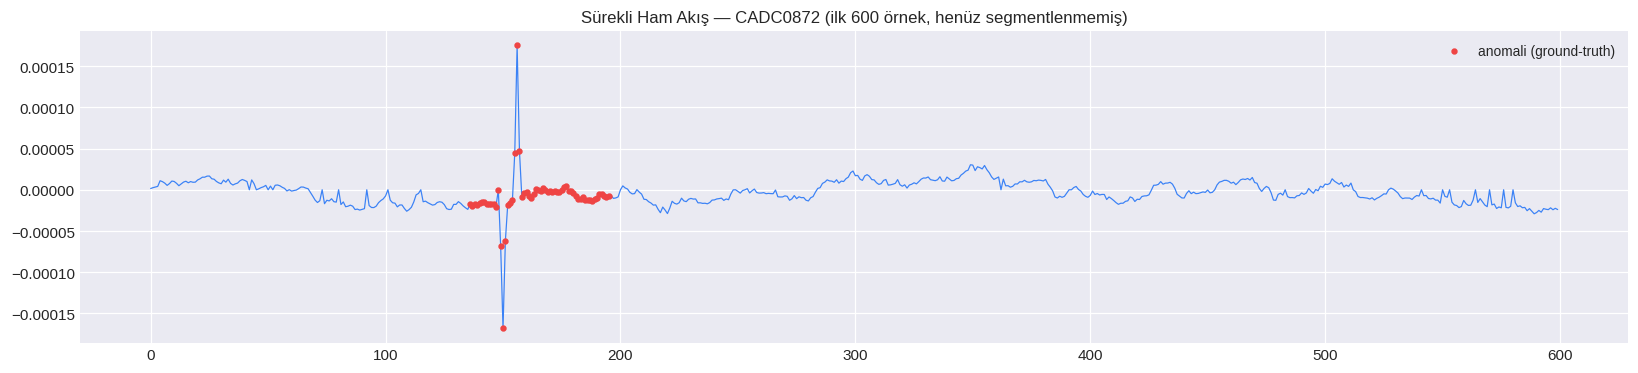

In [7]:
ch_raw = raw[raw['channel'] == 'CADC0872'].head(600).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(15, 3.5))
ax.plot(ch_raw['value'].values, color='#3B82F6', linewidth=0.8)
anom_pts = ch_raw.index[ch_raw['_anomaly_truth'] == 1]
ax.scatter(anom_pts, ch_raw.loc[anom_pts, 'value'], color='#EF4444', s=10, zorder=5, label='anomali (ground-truth)')
ax.set_title('Sürekli Ham Akış — CADC0872 (ilk 600 örnek, henüz segmentlenmemiş)', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


---
## Bölüm 6: Aşama 2, Hibrit Segmentasyon
`segment_raw_telemetry()`, ham akışı iki kademede segmentlere böler:

1. Boşluk-bölme: Δt, kampanya eşiğini (`max(gap_factor×sampling, min_gap_seconds=150s)`) aşarsa yeni koşu başlar. Bu eşik, onboard mikro-boşlukların ve büyük-boşluk artefaktlarının (en fazla 130 saniye) yanlışlıkla segment bölmesini önler.
2. Uzunluk-penceresi: Her koşu, kanalın gerçek segment uzunluk dağılımına (`len_mean`/`len_std`) uyan pencerelere bölünür.

Anomali etiketi türetilir: segment, anomali örneklerini eşik oranın (en az %10 veya en az 3 örnek) üzerinde içeriyorsa "anomaly". Bu, tek bir sızan örneğin komşu segmenti yanlış etiketlemesini önler.


In [8]:
segments = segment_raw_telemetry(raw, profiles=CHANNEL_PROFILES, seed=42)

print(f'\nSegments boyutu: {segments.shape}')
print(f'Sütunlar: {list(segments.columns)}  (artık segments.csv formatı)')
n_seg = segments['segment'].nunique()
n_anom = segments.groupby('segment')['anomaly'].first().sum()
print(f'Segment: {n_seg} | Anomali: {n_anom} (%{n_anom/n_seg*100:.1f}) | Satır: {len(segments):,}')
segments.head(6)


Segmentasyon tamamlandi: 571 segment (132 anomali, %23.1), 75,256 satir.

Segments boyutu: (75256, 8)
Sütunlar: ['channel', 'timestamp', 'value', 'label', 'sampling', 'anomaly', 'segment', 'train']  (artık segments.csv formatı)
Segment: 571 | Anomali: 132 (%23.1) | Satır: 75,256


,channel,timestamp,value,label,sampling,anomaly,segment,train
0,CADC0872,2023-01-01T20:35:56.000Z,0.000002,anomaly,1,1,1,1
1,CADC0872,2023-01-01T20:35:57.000Z,0.000003,anomaly,1,1,1,1
2,CADC0872,2023-01-01T20:35:58.000Z,0.000003,anomaly,1,1,1,1
3,CADC0872,2023-01-01T20:35:59.000Z,0.000004,anomaly,1,1,1,1
4,CADC0872,2023-01-01T20:36:00.000Z,0.000011,anomaly,1,1,1,1
5,CADC0872,2023-01-01T20:36:01.000Z,0.000010,anomaly,1,1,1,1


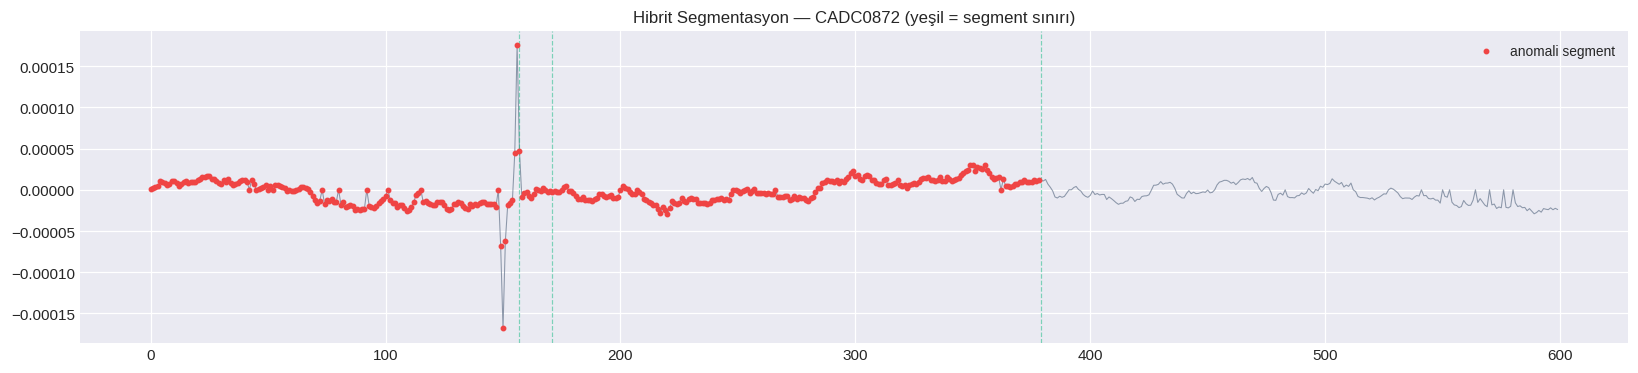

In [9]:
ch_seg = segments[segments['channel'] == 'CADC0872'].copy().reset_index(drop=True)
view = ch_seg.head(600)
fig, ax = plt.subplots(figsize=(15, 3.5))
ax.plot(view.index, view['value'].values, color='#64748B', linewidth=0.7, alpha=0.7)
bounds = view.index[view['segment'].diff().fillna(0) != 0]
for b in bounds:
    ax.axvline(b, color='#10B981', linestyle='--', alpha=0.5, linewidth=0.8)
anom_seg = view.index[view['anomaly'] == 1]
ax.scatter(anom_seg, view.loc[anom_seg, 'value'], color='#EF4444', s=8, zorder=5, label='anomali segment')
ax.set_title('Hibrit Segmentasyon — CADC0872 (yeşil = segment sınırı)', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


---
## Bölüm 7: Aşama 3, ESA Feature Extraction
Segmentlenmiş veriden, Notebook 10 ile aynı pipeline (`extract_esa_features`) 18 handcrafted özelliği çıkarır. Böylece `dataset.csv` formatı tamamlanır ve sentetik veri, gerçek veriyle aynı özellik uzayına taşınır.


In [10]:
dataset = extract_esa_features(segments)
print(f'\nDataset boyutu: {dataset.shape}  (23 sütun: 18 özellik + 5 meta)')
dataset.head()


  [200/571] segment isleniyor...


  [400/571] segment isleniyor...


  [571/571] segment isleniyor...
Tamamlandi: 571 segment, 18 ozellik cikarildi.

Dataset boyutu: (571, 23)  (23 sütun: 18 özellik + 5 meta)


,segment,anomaly,train,channel,sampling,duration,len,mean,var,std,...,smooth10_n_peaks,smooth20_n_peaks,diff_peaks,diff2_peaks,diff_var,diff2_var,gaps_squared,len_weighted,var_div_duration,var_div_len
0,1,1,1,CADC0872,1,152,157,-6.061274e-06,5.918067e-10,0.000024,...,3,1,6,7,3.335089e-10,4.841971e-10,152,157,3.893465e-12,3.769469e-12
1,2,1,1,CADC0872,1,13,14,3.228571e-07,1.783214e-10,0.000013,...,0,0,2,2,2.335583e-10,3.052238e-10,13,14,1.371703e-11,1.273725e-11
2,3,1,1,CADC0872,1,199,208,9.782260e-07,1.546239e-10,0.000012,...,4,4,41,48,1.139607e-11,2.569735e-11,199,208,7.770047e-13,7.433843e-13
3,4,0,0,CADC0872,1,219,230,-6.486161e-06,1.113717e-10,0.000011,...,5,3,42,57,2.490244e-11,6.360682e-11,219,230,5.085466e-13,4.842248e-13
4,5,0,1,CADC0872,1,13,14,-2.341695e-05,1.127734e-11,0.000003,...,0,0,3,3,9.951789e-12,2.509312e-11,13,14,8.674874e-13,8.055240e-13


---
## Bölüm 8: Doğrulama
Üç aşamanın da gerçeğe sadık olduğunu kanıtlıyoruz: segment uzunluk dağılımı, sinyal istatistikleri, anomali ayırt ediciliği.


In [11]:
real = pd.read_csv('../data/raw/segments.csv')

print('=== (a) Segment uzunluk dağılımı: gerçek vs üretilen ===')
rows = []
for ch in CHANNEL_PROFILES:
    rl = real[real['channel'] == ch].groupby('segment').size()
    sl = segments[segments['channel'] == ch].groupby('segment').size()
    if len(sl) == 0:
        continue
    rows.append({'Kanal': ch,
                 'Gerçek ort': round(rl.mean(), 0), 'Üretilen ort': round(sl.mean(), 0),
                 'Gerçek std': round(rl.std(), 0), 'Üretilen std': round(sl.std(), 0),
                 'Segment': len(sl)})
pd.DataFrame(rows)


=== (a) Segment uzunluk dağılımı: gerçek vs üretilen ===


,Kanal,Gerçek ort,Üretilen ort,Gerçek std,Üretilen std,Segment
0,CADC0872,122.0,105.0,115.0,78.0,155
1,CADC0873,115.0,108.0,111.0,89.0,150
2,CADC0874,303.0,326.0,256.0,223.0,49
3,CADC0884,75.0,71.0,39.0,36.0,42
4,CADC0888,46.0,41.0,22.0,20.0,78
5,CADC0892,236.0,225.0,93.0,96.0,56
6,CADC0894,247.0,192.0,230.0,138.0,41


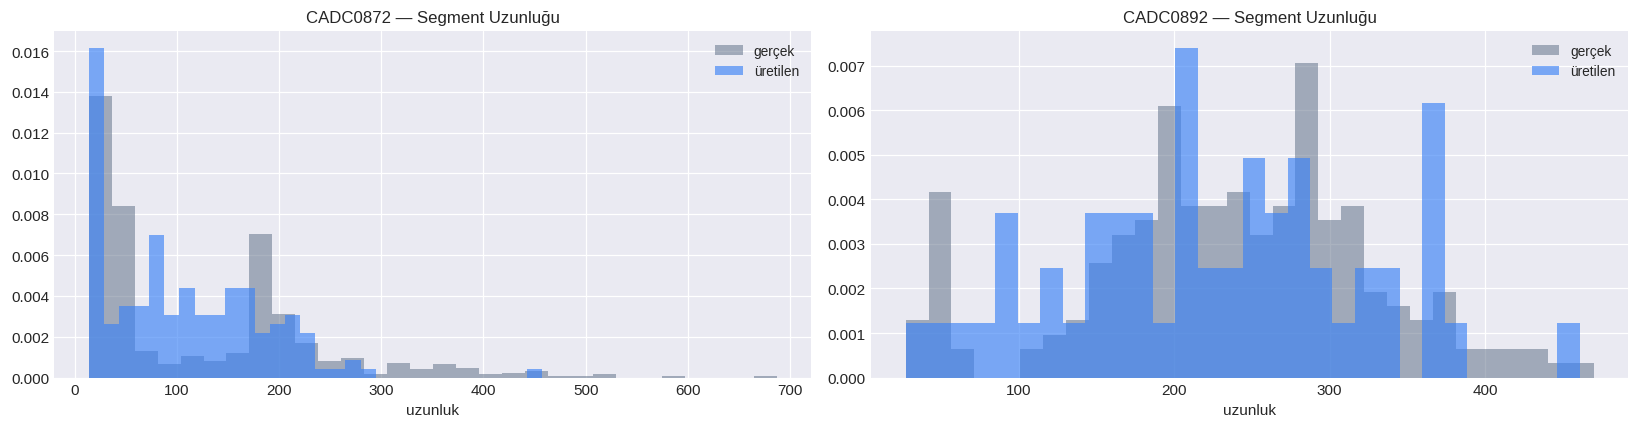

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for ax, ch in zip(axes, ['CADC0872', 'CADC0892']):
    rl = real[real['channel'] == ch].groupby('segment').size()
    sl = segments[segments['channel'] == ch].groupby('segment').size()
    ax.hist(rl, bins=30, alpha=0.55, color='#64748B', label='gerçek', density=True)
    ax.hist(sl, bins=30, alpha=0.65, color='#3B82F6', label='üretilen', density=True)
    ax.set_title(f'{ch} — Segment Uzunluğu', fontsize=11)
    ax.set_xlabel('uzunluk'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


In [13]:
print('=== (b) Fotodiyot sinyal sadakati (ort/max, sıfır-değer hariç) ===')
for ch in ['CADC0884', 'CADC0892', 'CADC0894']:
    mx = CHANNEL_PROFILES[ch]['signal_max']
    rv = real[(real['channel'] == ch) & (real['anomaly'] == 0)]['value']; rv = rv[rv != 0]
    sv = segments[(segments['channel'] == ch) & (segments['anomaly'] == 0)]['value']; sv = sv[sv != 0]
    print(f'  {ch}: gerçek={rv.mean()/mx:.3f}  üretilen={sv.mean()/mx:.3f}')

print('\n=== (c) Anomali ayırt ediciliği (LogReg 5-fold F1) ===')
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
feats = ['mean', 'var', 'std', 'kurtosis', 'skew', 'n_peaks', 'smooth10_n_peaks', 'diff_var', 'diff2_var']
X = StandardScaler().fit_transform(dataset[feats].fillna(0).replace([np.inf, -np.inf], 0))
f1 = cross_val_score(LogisticRegression(max_iter=1000), X, dataset['anomaly'], cv=5, scoring='f1')
print(f'  F1: {f1.mean():.3f} +/- {f1.std():.3f}  (özellikler anomaliyi ayırt edebiliyor)')


=== (b) Fotodiyot sinyal sadakati (ort/max, sıfır-değer hariç) ===


  CADC0884: gerçek=0.353  üretilen=0.379
  CADC0892: gerçek=0.274  üretilen=0.315
  CADC0894: gerçek=0.165  üretilen=0.248

=== (c) Anomali ayırt ediciliği (LogReg 5-fold F1) ===
  F1: 0.390 +/- 0.086  (özellikler anomaliyi ayırt edebiliyor)


---
## Bölüm 9: Kaydetme ve Pipeline Özeti
Üç aşamanın çıktısını ayrı dosyalara kaydediyoruz. Gerçek `data/raw/` dosyaları ezilmez.


In [14]:
os.makedirs('../data/synthetic', exist_ok=True)

raw.to_csv('../data/synthetic/synthetic_raw_stream.csv', index=False)
segments.to_csv('../data/synthetic/synthetic_segments.csv', index=False)
dataset.to_csv('../data/synthetic/synthetic_dataset.csv', index=False)

print('Kaydedildi:')
print(f'  Aşama 1  synthetic_raw_stream.csv  ({len(raw):,} satır)')
print(f'  Aşama 2  synthetic_segments.csv    ({segments["segment"].nunique()} segment)')
print(f'  Aşama 3  synthetic_dataset.csv     ({dataset.shape[0]} segment × {dataset.shape[1]} sütun)')


Kaydedildi:
  Aşama 1  synthetic_raw_stream.csv  (75,256 satır)
  Aşama 2  synthetic_segments.csv    (571 segment)
  Aşama 3  synthetic_dataset.csv     (571 segment × 23 sütun)


### Özet
Bu notebook, sentetik telemetriyi gerçek yaşam döngüsüne sadık üç ayrı aşamada üretir:

| Aşama | Fonksiyon | Çıktı | Gerçek-veri dayanağı |
|-------|-----------|-------|----------------------|
| 1. Ham üretim | `generate_raw_stream` | sürekli akış | sinyal stats ve kampanya yapısı |
| 2. Segmentasyon | `segment_raw_telemetry` | `segments.csv` | uzunluk dağılımı ve boşluk eşikleri |
| 3. Özellik çıkarımı | `extract_esa_features` | `dataset.csv` | ESA 18 handcrafted feature |

Segmentasyon artık gerçek bir algoritma adımıdır, sahte değil. Anomali etiketi atanmaz, ham akıştan türetilir. Bu, segmentasyon kalitesinin etiket istatistiklerini nasıl etkilediğini de gözlemlenebilir kılar.

Üretilen `synthetic_dataset.csv`, Notebook 04 ve 05 ile model eğitimine girebilir.
